# 02 — Frame Labeling

**Primary path (free):** Run the aggregate query (generated dynamically from
`src/dictionaries.py` via `src/build_query.py`) and inspect the frame distributions. No
per-article data needed.

**Secondary path (spot-checking only):** Run the full raw extraction and the Python
preprocessing pipeline to manually verify that the frame labels make sense.

Both query/save cells below overwrite `data/processed/monthly_frames.csv` and
`data/raw/gdelt_genai_gov.csv` unconditionally — the lexicons/queries changed since those
files were last produced (see `MERGE_PLAN.md`), so the previous skip-if-exists guards have
been removed to avoid silently analyzing stale data.

Start with Part A. Only run Part B if you want to audit individual article examples.

### Grounding

Coding articles into a small set of generic frames via keyword dictionaries follows
Semetko & Valkenburg (2000)'s methodological precedent, building on Entman (1993)'s
definition of framing/salience. DiMaggio et al. (2013) is the explicit counterpoint —
topic modeling can surface latent structure a fixed dictionary will miss — cited here as
the tradeoff this project consciously accepts for transparency and reproducibility over
discovery. See `MERGE_PLAN.md`'s grounding map for the full citation-to-design-choice
mapping.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import load_agg, monthly_volume_agg, frame_shares_agg
from src.dictionaries import MILESTONES

sns.set_theme(style='whitegrid', palette='colorblind')

---
## Part A — Aggregated path (primary)

Generates the aggregate query dynamically from `src/dictionaries.py` and runs it via
BigQuery, overwriting `data/processed/monthly_frames.csv`.

In [4]:
import os
from pathlib import Path
from google.cloud import bigquery

from src.build_query import build_aggregate_query

AGG_PATH = Path('../data/processed/monthly_frames.csv')
if AGG_PATH.exists():
    print(f'Overwriting stale {AGG_PATH} (lexicons/queries changed since it was last produced).')

PROJECT = os.environ.get('BIGQUERY_PROJECT', 'genai-gdelt')
client = bigquery.Client(project=PROJECT)
sql = build_aggregate_query()
print('Running aggregate_frames query (generated from src/dictionaries.py) ...')
df_bq = client.query(sql).to_dataframe()
AGG_PATH.parent.mkdir(parents=True, exist_ok=True)
df_bq.to_csv(AGG_PATH, index=False)
print(f'Saved {len(df_bq)} rows -> {AGG_PATH}')

Overwriting stale ../data/processed/monthly_frames.csv (lexicons/queries changed since it was last produced).
Running aggregate_frames query (generated from src/dictionaries.py) ...
Saved 44 rows -> ../data/processed/monthly_frames.csv


In [3]:
agg_df = load_agg(AGG_PATH)
print(f'Loaded {len(agg_df)} months, {agg_df["total_articles"].sum():,} total articles')
agg_df.head()

Loaded 44 months, 1,104,618 total articles


,month,total_articles,frame_innovation_opportunity,frame_risk_safety,frame_regulation_governance,frame_rights_privacy,frame_economic_competition_labour,frame_misinformation_integrity
0,2022-11,17143,1634,1815,4941,356,1978,854
1,2022-12,14838,1816,1779,4650,521,1975,315
2,2023-01,15361,2083,1662,5101,384,2177,288
3,2023-02,15465,2058,1977,5332,644,2578,309
4,2023-03,21737,2931,3114,7924,717,3403,388


In [7]:
# Monthly totals
vol = monthly_volume_agg(agg_df)
print('Date range:', vol.index[0], '→', vol.index[-1])
print('Peak month:', vol.idxmax(), '—', vol.max(), 'articles')
vol.tail()

Date range: 2022-11 → 2026-06
Peak month: 2025-03 — 31120 articles


month
2026-02    25930
2026-03    28696
2026-04    27025
2026-05    28204
2026-06    18503
Freq: M, Name: count, dtype: int64

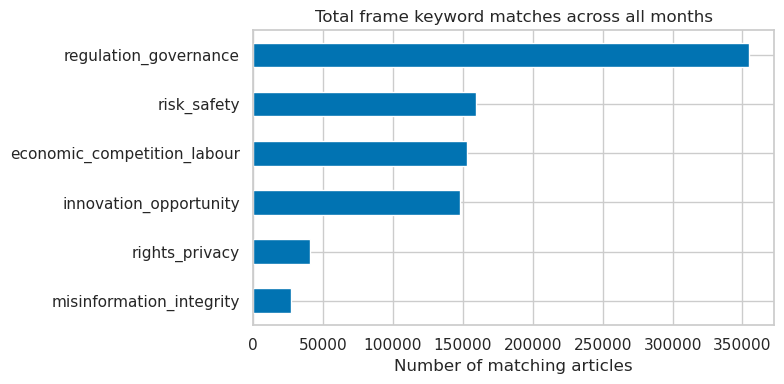


Frame totals:
regulation_governance          354800
risk_safety                    159715
economic_competition_labour    153244
innovation_opportunity         148015
rights_privacy                  40668
misinformation_integrity        26742
dtype: int64


In [5]:
# Frame hit totals across all months
frame_cols = [c for c in agg_df.columns if c.startswith('frame_')]
frame_totals = agg_df[frame_cols].sum().rename(index=lambda x: x.replace('frame_', ''))

fig, ax = plt.subplots(figsize=(8, 4))
frame_totals.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Total frame keyword matches across all months')
ax.set_xlabel('Number of matching articles')
plt.tight_layout()
plt.show()

print('\nFrame totals:')
print(frame_totals.sort_values(ascending=False))

In [6]:
# Frame shares over time
shares = frame_shares_agg(agg_df)
shares.head()

,innovation_opportunity,risk_safety,regulation_governance,rights_privacy,economic_competition_labour,misinformation_integrity
month,,,,,,
2022-11,0.141130,0.156763,0.426758,0.030748,0.170841,0.073761
2022-12,0.164255,0.160908,0.420586,0.047124,0.178636,0.028491
2023-01,0.178110,0.142112,0.436169,0.032835,0.186148,0.024626
2023-02,0.159560,0.153280,0.413397,0.049930,0.199876,0.023957
2023-03,0.158630,0.168534,0.428857,0.038805,0.184175,0.020999


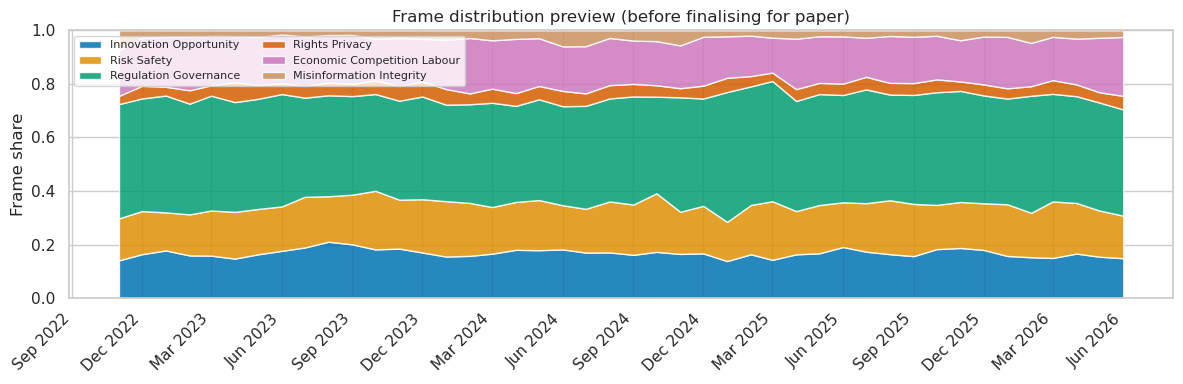

In [7]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
dates = shares.index.to_timestamp()
ax.stackplot(
    dates,
    [shares[col] for col in shares.columns],
    labels=[c.replace('_', ' ').title() for c in shares.columns],
    alpha=0.85,
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Frame share')
ax.set_ylim(0, 1)
ax.set_title('Frame distribution preview (before finalising for paper)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
### Governance coverage rate

Query the **total** monthly GenAI article count (no governance filter) and compare it
against our governance-filtered corpus to show what fraction of all AI coverage is
governance-related.

This uses the same GenAI filter as the main corpus but drops the governance `AND` clause,
so the result is a broader denominator. The query only does a monthly `COUNT(*)` — no
text is exported — so it is cheap and fast.

Result saved to `data/processed/monthly_ai_total.csv` (44 rows).

Running total-AI count query (no governance filter) …
Saved 44 rows → ../data/processed/monthly_ai_total.csv
      month  total_ai_articles
0   2022-11              19522
1   2022-12              16904
2   2023-01              18850
3   2023-02              18467
4   2023-03              24753
5   2023-04              32522
6   2023-05              32112
7   2023-06              30793
8   2023-07              25092
9   2023-08              26692
10  2023-09              28849
11  2023-10              28297
12  2023-11              28830
13  2023-12              24665
14  2024-01              25845
15  2024-02              33639
16  2024-03              29827
17  2024-04              27184
18  2024-05              27828
19  2024-06              31347
20  2024-07              30167
21  2024-08              25951
22  2024-09              28785
23  2024-10              28378
24  2024-11              33197
25  2024-12              28436
26  2025-01              31818
27  2025-02            

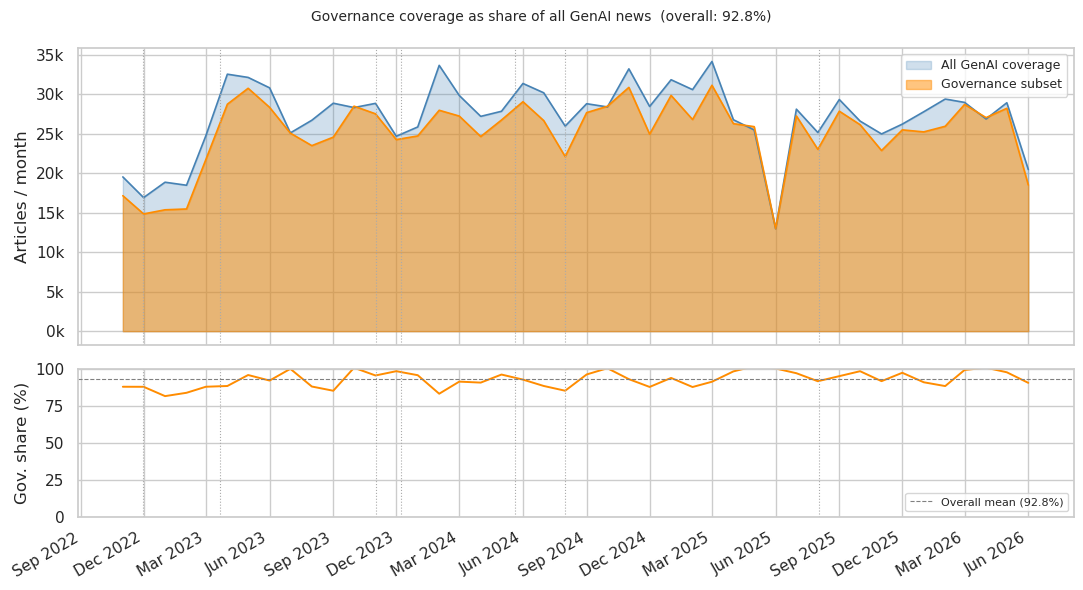

In [5]:
import os
import matplotlib.dates as mdates
from pathlib import Path
from google.cloud import bigquery
from src.build_query import build_genai_filter
from src.dictionaries import STUDY_START_DATE, STUDY_END_DATE

AI_TOTAL_PATH = Path('../data/processed/monthly_ai_total.csv')

# ── 1. Query BigQuery for total GenAI monthly counts (governance-free) ────────
PROJECT = os.environ.get('BIGQUERY_PROJECT', 'genai-gdelt')
client = bigquery.Client(project=PROJECT)

genai_filter = build_genai_filter(style='like', indent=4)

sql_ai_total = f"""
SELECT
  FORMAT_DATE(
    '%Y-%m',
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8))
  ) AS month,
  COUNT(*) AS total_ai_articles
FROM `gdelt-bq.gdeltv2.gkg_partitioned`
WHERE DATE(_PARTITIONTIME) >= '{STUDY_START_DATE}'
  AND DATE(_PARTITIONTIME) <= '{STUDY_END_DATE}'
  AND (TranslationInfo IS NULL OR TranslationInfo = '')
  AND {genai_filter}
GROUP BY month
ORDER BY month
"""

print('Running total-AI count query (no governance filter) …')
df_ai = client.query(sql_ai_total).to_dataframe()
AI_TOTAL_PATH.parent.mkdir(parents=True, exist_ok=True)
df_ai.to_csv(AI_TOTAL_PATH, index=False)
print(f'Saved {len(df_ai)} rows → {AI_TOTAL_PATH}')
print(df_ai)

# ── 2. Merge with governance corpus totals ────────────────────────────────────
agg_df = load_agg(AGG_PATH)  # already loaded above in Part A

df_gov = agg_df[['month', 'total_articles']].copy()
df_gov['month'] = df_gov['month'].astype(str)

merged = df_ai.merge(df_gov, on='month')
merged['gov_share'] = merged['total_articles'] / merged['total_ai_articles']
merged['month_ts'] = pd.to_datetime(merged['month'])

overall_share = merged['total_articles'].sum() / merged['total_ai_articles'].sum()
print(f'\nOverall governance share: {overall_share:.1%}  '
      f'({merged["total_articles"].sum():,} of {merged["total_ai_articles"].sum():,} GenAI articles)')

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Panel A: absolute volumes
ax1.fill_between(merged['month_ts'], merged['total_ai_articles'],
                 alpha=0.25, color='steelblue', label='All GenAI coverage')
ax1.plot(merged['month_ts'], merged['total_ai_articles'],
         linewidth=1.2, color='steelblue')
ax1.fill_between(merged['month_ts'], merged['total_articles'],
                 alpha=0.5, color='darkorange', label='Governance subset')
ax1.plot(merged['month_ts'], merged['total_articles'],
         linewidth=1.2, color='darkorange')
ax1.set_ylabel('Articles / month')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax1.legend(fontsize=9)

# Panel B: governance share %
ax2.plot(merged['month_ts'], merged['gov_share'] * 100,
         linewidth=1.4, color='darkorange')
ax2.axhline(overall_share * 100, color='grey', linestyle='--', linewidth=0.8,
            label=f'Overall mean ({overall_share:.1%})')
ax2.set_ylabel('Gov. share (%)')
ax2.set_ylim(0, min(100, merged['gov_share'].max() * 130))
ax2.legend(fontsize=8)

for name, ts in {m['name']: pd.Timestamp(m['date']) for m in MILESTONES}.items():
    for ax in (ax1, ax2):
        ax.axvline(ts, color='#aaa', linestyle=':', linewidth=0.8)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Governance coverage as share of all GenAI news  (overall: {overall_share:.1%})',
             fontsize=10)
plt.tight_layout()
plt.show()

### Sanity checks

Look for:
- Any months with suspiciously high or low totals (data gaps)
- Frame shares that seem implausible (e.g. one frame dominating at >80%)
- A visible uptick around Nov 2022 (ChatGPT launch) — if absent, revisit the GenAI filter

In [9]:
# Months with unusually low article counts (potential data gaps)
mean_vol = vol.mean()
low = vol[vol < mean_vol * 0.3]
if low.empty:
    print('No low-volume months detected.')
else:
    print('Potential data gaps:')
    print(low)

No low-volume months detected.


---
## Part B — Raw article spot-check

Only run this section if you want to audit individual articles by frame label.

**To get the corpus (~3.6 GB CSV):** either
- Run the dry-run cell below to confirm cost, then the BQ extraction cell, **or**
- Use the Google Drive download cell (faster if you have the sharing link).

In [9]:
# Dry-run: see bytes scanned before committing
import os
from google.cloud import bigquery
from src.build_query import build_extract_query

PROJECT = os.environ.get('BIGQUERY_PROJECT', 'genai-gdelt-499513')
client = bigquery.Client(project=PROJECT)
extract_sql = build_extract_query()

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry = client.query(extract_sql, job_config=job_config)
gb = dry.total_bytes_processed / 1e9
tb = dry.total_bytes_processed / 1e12
print(f'extract_genai_gov query would scan {gb:.1f} GB  ({tb:.2f} TB)')
print(f'Estimated cost beyond free tier: ~${max(0, tb - 1) * 5:.2f}  (at $5/TB)')
print('Status:', 'SAFE (within 1 TB free tier)' if tb < 1 else f'CHARGEABLE — {tb:.2f} TB')

extract_genai_gov query would scan 872.1 GB  (0.87 TB)
Estimated cost beyond free tier: ~$0.00  (at $5/TB)
Status: SAFE (within 1 TB free tier)


In [10]:
# Full extraction — only run after confirming cost above. Overwrites unconditionally:
# the lexicons/queries changed since any previous data/raw/gdelt_genai_gov.csv was
# produced, so a stale skip-if-exists guard would silently reuse old data.
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')
if RAW_PATH.exists():
    print(f'Overwriting stale {RAW_PATH} (lexicons/queries changed since it was last produced).')

print('Running extract_genai_gov query — this may take several minutes ...')
df_raw = client.query(extract_sql).to_dataframe()
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(RAW_PATH, index=False)
print(f'Saved {len(df_raw):,} rows -> {RAW_PATH}')

Overwriting stale ../data/raw/gdelt_genai_gov.csv (lexicons/queries changed since it was last produced).
Running extract_genai_gov query — this may take several minutes ...
Saved 1,104,632 rows -> ../data/raw/gdelt_genai_gov.csv


In [ ]:
# --- Alternative entry point to the cell above: download a pre-extracted corpus from
# Google Drive instead of querying BigQuery yourself. Skip this cell if you already ran
# the extraction above. ---
# 1. Upload gdelt_genai_gov.csv to personal Google Drive
# 2. Right-click → Share → 'Anyone with the link' → Copy link
# 3. Paste the file ID below (the part between /d/ and /view in the URL)
# pip install gdown  (if not already installed)
import gdown
from pathlib import Path

GDRIVE_FILE_ID = "1q2wkv877hodP7gwJTGzrcsXMw7RDthRU"  # ← e.g. '1aBcDeFgHiJkLmNoPqRsTuVwXyZ'
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')

if RAW_PATH.exists():
    print(f'Already exists: {RAW_PATH}  ({RAW_PATH.stat().st_size / 1e9:.1f} GB)')
else:
    RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
    gdown.download(url, str(RAW_PATH), quiet=False)

In [11]:
RAW_PATH = Path('../data/raw/gdelt_genai_gov.csv')
if not RAW_PATH.exists():
    print('Raw corpus not found — skip this section.')
else:
    from src.preprocessing import load_raw, run_pipeline
    from src.dictionaries import FRAME_DICTS

    raw_df = load_raw(RAW_PATH)
    df = run_pipeline(raw_df)
    print(f'Loaded {len(df):,} articles after dedup')

Loaded 1,103,744 articles after dedup


`run_pipeline` now also calls `extract_headline_from_url`, which derives a readable
headline from each article's URL slug and backfills it into `Quotations` for rows where
that field was empty/NaN. A large share of GKG records have empty `Quotations`, which
previously starved keyword/frame matching for those rows (flagged by this notebook's own
spot-check below). See `src/preprocessing.py` for the implementation.

In [12]:
# Save preprocessed corpus for Figure 4 (regional comparison) and Figures 5-6 (tone).
# Overwrites unconditionally — see the note on the extraction cell above.
INTERIM_PATH = Path('../data/interim/gdelt_preprocessed.parquet')
if 'df' in dir():
    if INTERIM_PATH.exists():
        print(f'Overwriting stale {INTERIM_PATH} (lexicons/queries changed since it was last produced).')
    INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(INTERIM_PATH, index=False)
    print(f'Saved {len(df):,} rows -> {INTERIM_PATH}')
else:
    print('df not available — run the pipeline cell above first.')

Overwriting stale ../data/interim/gdelt_preprocessed.parquet (lexicons/queries changed since it was last produced).
Saved 1,103,744 rows -> ../data/interim/gdelt_preprocessed.parquet


In [13]:
# Sample 10 articles per dominant frame to verify labels (per MERGE_PLAN.md's
# recommended follow-up: manually sample ~10 articles per frame now that real
# reconciled data exists to sample from).
if 'df' in dir() and 'dominant_frame' in df.columns:
    SPOT_COLS = ['DATE', 'SourceCommonName', 'dominant_frame', 'Quotations']
    for frame_name in FRAME_DICTS:
        n_frame = (df['dominant_frame'] == frame_name).sum()
        if n_frame == 0:
            continue
        sample = df[df['dominant_frame'] == frame_name][SPOT_COLS].sample(
            min(10, n_frame), random_state=42
        )
        print(f'\n=== {frame_name} (n={n_frame:,}) ===')
        for _, row in sample.iterrows():
            print(f'  [{row["DATE"]}] {row["SourceCommonName"]}')
            print(f'  {str(row["Quotations"])[:250]}')


=== innovation_opportunity (n=127,507) ===
  [2026-06-12 00:00:00] ilsole24ore.com
  vannacci via l assemblea costituente partito generale prepara contrattacco meloni aivxondd
  [2026-02-02 00:00:00] wncw.org
  2356|70||could not demonstrate that it included all potential costs and savings
  [2023-11-01 00:00:00] itnewsonline.com
  blockchain technology market size to grow by usd 61 million from to the rising venture capital investments to drive the market growth technavio
  [2022-11-10 00:00:00] printweek.com
  675|31||later this year/early next year#8382|94||we will start to take orders in q3 and q4 this year , with a view to production in q1 2014 .
  [2023-12-07 00:00:00] clarin.com
  seducis signo zodiacal tacticas secretas 0 7wawosuyyd
  [2025-08-02 00:00:00] 20minutos.es
  horoscopo domingo 03 agosto 0
  [2022-12-14 00:00:00] rte.ie
  13780|49|| adopted by states in the decade since sandy hook
  [2023-04-21 00:00:00] mopo.de
  heftige kaempfe im sudan gehen weiter lage fuer deut